# Cluster Dataset (2x SIE)

In this demo we show the generation of a dataset for machine
learning sporting two SIE lenses.
To run the notebook, you will have to download several datafiles
from [](Cluster2.md).

::: {warning} 
This demo uses a feature from CosmoSim v3.2, taking the Critical Curve
into account when placing the sources.  This will not work in v3.1.
:::

## Preparation

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import json
from CosmoSim.datagen import SimImage
import CosmoSim.Image as csimg
import CosmoSim.dataset as csd
from CosmoSim import Parameters

The distribution of the dataset is configured as follows.

In [12]:
cfg = csd.readtoml( "cluster2-dataset.toml" )
display( json.dumps( cfg ) )

'{"simulator": {"model": "Raytrace", "size": 15000, "nterms": 4, "imagesize": 512, "cropsize": 256, "centred": true}, "dataset": {"directory": "images"}, "lens": {"mode": "SIE", "einstein-min": 3, "einstein-max": 75, "orientation-min": 0, "orientation-max": 180, "ellipseratio-min": 0.1, "ellipseratio-max": 0.9}, "cluster": {"count": 2, "maxrelativelocation": 1.2}, "source": {"mode": "SersicSphere", "n_sersic-min": 1, "n_sersic-max": 5, "luminosity-min": 20, "luminosity-max": 80, "luminosity-lambda": 2.0, "sigma-min": 5, "sigma-max": 50, "position": "critical"}, "position": {"phi-min": 0, "phi-max": 360, "r-relativemax": 1.2}}'

Each constituent lens is placed in a random direction from the origin,
at a random distance upper bounded as $c\theta_E$ where $\theta_E$ is
the Einstein radius and $c$ is the constant given as `cluster.maxrelativelocation`.

We can draw a random object as before.

## A sample

Let us make a random sample for review.
Firstly, we make a convenience function to run one simulation and
retrieve the image.

In [13]:
def mkimg(ob):
      p0 = Parameters( )
      p0.setRow( ob )
      sim = SimImage( p0, verbose=0 )
      return sim.getImage()

Using this function, we can make a list of simulations, and plot the
results.

[getline] idx=0
[CosmoSim/py] setCluster(SIE/28.43728630943311/-5.78832710009015/66.22984621507084/0.5292326698488999/125.47400900617467;SIE/-24.24180604644283/-78.01135302741592/70.41705371524507/0.46247865769224006/36.477155462762305)
[getline] idx=0
[CosmoSim/py] setCluster(SIE/-8.220483513103725/-7.598902563627487/70.54770263359492/0.7542264626962218/29.122412121657696;SIE/5.05356472489003/-3.3910085355747013/25.733020447774962/0.1825839114662534/29.13340087050252)
[getline] idx=0
[CosmoSim/py] setCluster(SIE/-10.444084154818615/4.461671837493301/14.40023677404158/0.8366915829748005/171.33967875794437;SIE/0.18510827684470546/6.457635192558407/18.79364399822994/0.5384936189770145/154.5422166858821)
[getline] idx=0
[CosmoSim/py] setCluster(SIE/-2.0250068872048352/-9.277314306442449/9.45521342232571/0.334081662700652/44.06759644770828;SIE/1.9036505924793914/0.9579613614526692/32.70806732825106/0.15682614326004593/59.99874352213997)
[getline] idx=0
[CosmoSim/py] setCluster(SIE/-27.7778

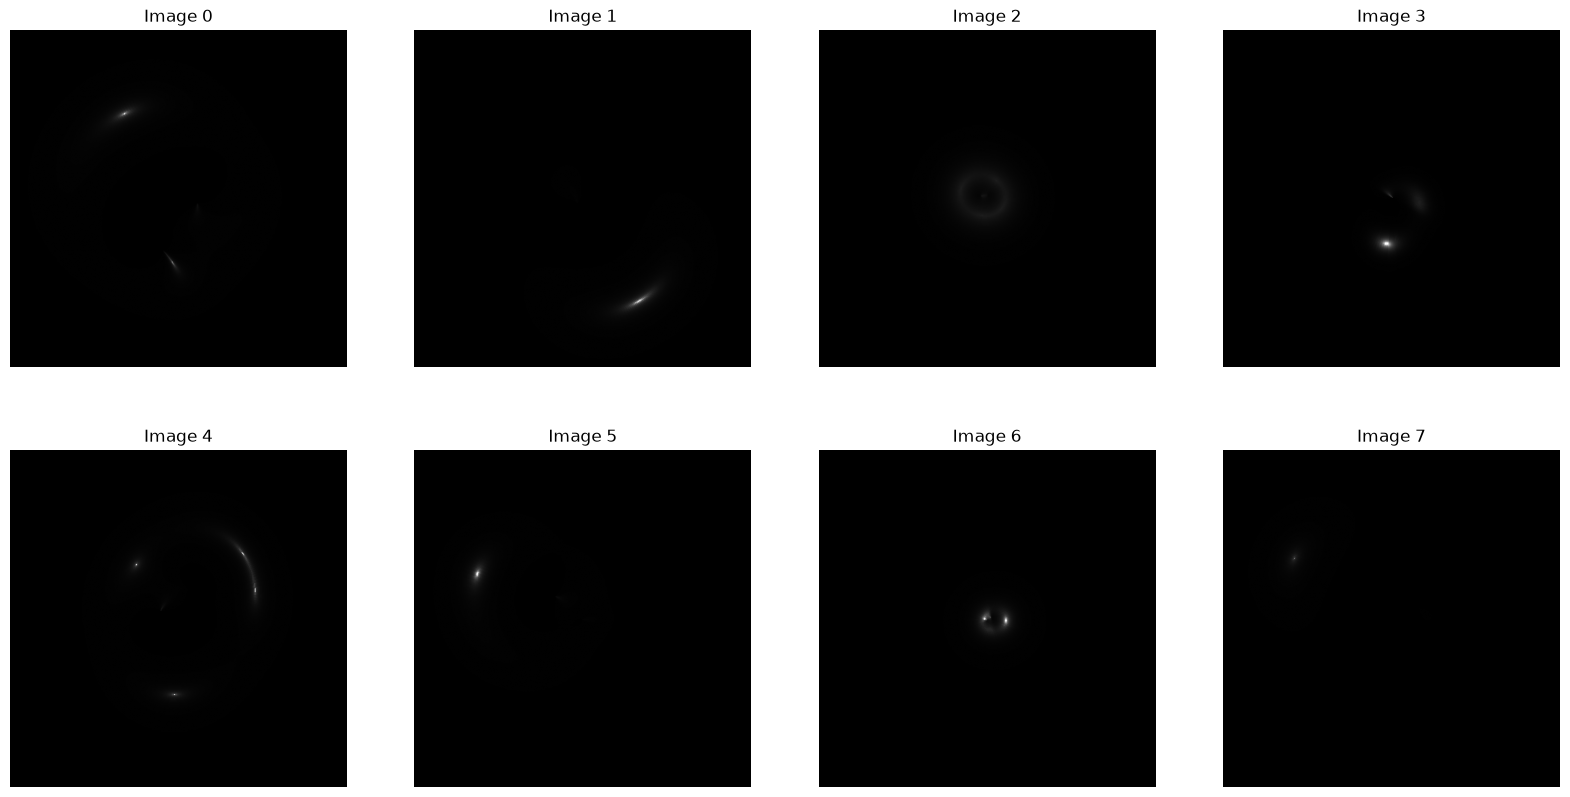

In [14]:
obs = [ csd.getline( cfg ) for _ in range(8) ]
ims = [ mkimg(ob) for ob in obs ]
ts = [ f"Image {i}" for i in range(8) ]
csimg.showImages( ims, size=(2,4), titles=ts )

If we take a particular  interest in one particular image, say no 1, we can easily inspect its parameters.

In [15]:
print( obs[1] )

index                                                         0
filename                                       image-000000.png
model                                                  Raytrace
cluster       SIE/-8.220483513103725/-7.598902563627487/70.5...
source                                             SersicSphere
R                                                     94.264593
phi                                                  296.339904
sigma                                                 48.974389
sigma2                                                12.609324
theta                                                118.154755
n_sersic                                               4.571992
luminosity                                            66.279283
x                                                     41.824771
y                                                    -84.477819
dtype: object


The cluser specification does not show in the row view, but we can single that one out to see properly.

In [16]:
print( obs[1]["cluster"] )

SIE/-8.220483513103725/-7.598902563627487/70.54770263359492/0.7542264626962218/29.122412121657696;SIE/5.05356472489003/-3.3910085355747013/25.733020447774962/0.1825839114662534/29.13340087050252


## Annotations

It may be interesting to look at the Critical Curves, to get an idea of the shape of the lenses.
Instead of `mkimg()` we make a function to get annotated images.

In [17]:
def mkannotation(ob):
      p0 = Parameters( )
      p0.setRow( ob )
      sim = SimImage( p0, verbose=0 )
      return sim.getAnnotated()

We use the same datasets as before, but generate new and annotated images.

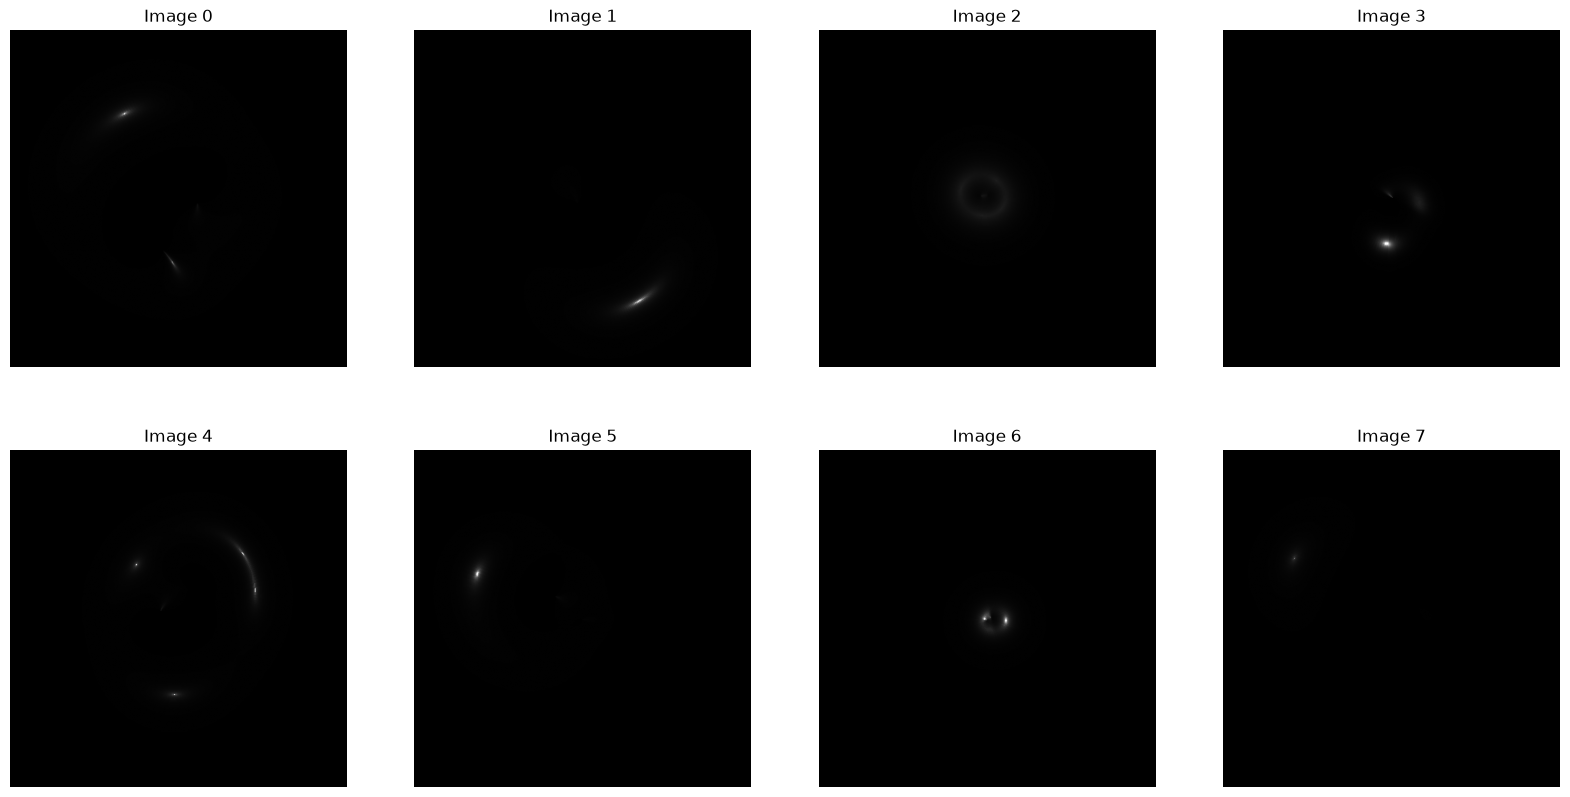

In [18]:
ims = [ mkimg(ob) for ob in obs ]
csimg.showImages( ims, size=(2,4), titles=ts )

The yellow curve is the Critical Curve, and the blue circle is the convergence
ring of the roulette formalism.
The red point is the centre of light.

## Closure

We have attemmpted to design the dataset so that it displays interesting
samples of strong lensing.  
More research is needed on actual distributions of observed lenses, and
how a representative sample can be designed for machine learning.